# Falling-Knife — a quantitative teardown 🔬
### Random-day null · block bootstrap · deflated Sharpe · capacity · out-of-sample

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We don't test *one* "buy the −3% dip" rule; we test a **family** of them and hold each to the only yardstick that matters: does it beat buying on a **random day**, after realistic costs, and does it survive out-of-sample?

> ⚠️ **Not investment advice.** Data: Yahoo! Finance via the study's `data` module, mode `split_only`. First run hits the network (^NDX, QQQ, ^GSPC, SPY); later runs use the parquet cache. House style, beats and protocol: [METHODOLOGY.md](../../../METHODOLOGY.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition — so this notebook still reads even if you skim the maths. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # study root (falling_knife/ lives there)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from falling_knife import data, triggers, exits, eventstudy, benchmark, backtest, robustness, sweeps


## Verdict, up front

| Axis | Stamp | Why (one line) |
|---|---|---|
| **Signal** — is the effect statistically real? | `NONE` @ −3% · `WEAK` deep | At −3% the excess over a random day is ~0 (p≈0.8 on ^NDX); a real bounce only appears at −5%/−7%. |
| **Tradability** — survives costs, capacity, scale? | `MIRAGE` | Deep-dip excess straddles zero under a clustering-aware bootstrap; ~3 events/decade dominated by 2–3 crashes; fixed rule flips +1.3→−1.4 Sharpe out-of-sample. |

> 💡 **In plain words** — the round number is a myth, the one real effect lives in rare panics you can't build a business on, and every flashy backtest Sharpe here turns out to be the market's drift in disguise.

## 1 · The claim, and why it's really a *family* of claims

"Buy the −3% Nasdaq dip" sounds like one rule, but a single threshold is not a single strategy. There are at least four defensible ways to define "the falling knife", and they can disagree wildly:

| ID | Definition | Reads as |
|---|---|---|
| **T1** | session **closes** ≤ −3% | the classic down-3%-day |
| **T2** | trades ≤ −3% below the open **intraday** | most reactive, same-day fill |
| **T3** | close ≥ 3% below a **rolling high** (drawdown) | the slide already started |
| **T4** | **cumulative** return over N days ≤ −3% | the slow bleed |

Multiply by a grid of exits (time / take-profit / stop / hybrid) and you have a whole **family**. Testing the family — not one lucky member — is the only honest way, because scanning dozens of rules guarantees one looks great by chance. The triggers loaded:

In [2]:
print('Triggers :', list(triggers.TRIGGERS.keys()))
print('Exit grid:', len(exits.default_grid()), 'rules  ->  family =',
      len(triggers.TRIGGERS)*len(exits.default_grid()), '(trigger x exit) combos')

Triggers : ['T1_close_to_close', 'T2_intraday', 'T3_drawdown_20d', 'T3_drawdown_ATH', 'T4_cum_5d']
Exit grid: 14 rules  ->  family = 70 (trigger x exit) combos


## 2 · So what? — the absolute-Sharpe trap

Here's what rides on getting this right, stated as the mistake almost every dip backtest makes. In a synthetic market with **no dip-edge at all** — just upward drift and clustered volatility — a family scan still coughs up a rule with **Sharpe > 2** (run `examples/run_synthetic_demo.py`). It isn't skill; it's the market's drift, harvested by an asymmetric take-profit/stop and dressed up as alpha.

Deflating that Sharpe for the search helps only if you count honestly: use the **active days actually behind the winner** (these rules are flat >90% of the time), not the calendar length — inflate `n_obs` to the full sample and even the drift-harvester "survives selection". And deflation at its best only rules out selection luck, never drift: the tool that exposes the fake is the conditional-vs-random-day benchmark (excess ≈ 0). So the stakes here are methodological: *a high backtest Sharpe can be pure beta.* Everything below is built to not get fooled by it.

## 3 · How we'd know — the protocol, declared up front

Announced before we run it. Five methodological commitments, each targeting a specific way to fool yourself:

1. **Excess over a random-day null**, by permutation — never absolute return. *(kills the drift illusion)*
2. **Block bootstrap**, because −3% days cluster (2008, 2020, 2022): 60 raw events may be ~10 independent episodes. *(kills fake significance)*
3. **Deflated Sharpe** over the whole (trigger × exit) grid, because scanning dozens of rules guarantees a lucky winner. *(kills selection bias)*
4. **Conservative fills** — when a bar touches both stop and target, the stop wins. *(kills optimistic backtests)*
5. **Panic slippage** — a separate entry-only cost, because you buy into a crash when spreads gape. *(kills the cost most dip studies forget)*

**What would make us stamp `MIRAGE`:** an excess that vanishes under the bootstrap, capacity of a handful of events, or a rule that flips sign out-of-sample. Let's run it on two faces of the market — **^NDX** (spot, deep history) and **QQQ** (the tradeable ETF).

In [3]:
ndx = data.fetch('^NDX', mode='split_only'); ret_ndx = data.daily_returns(ndx)
qqq = data.fetch('QQQ', mode='split_only'); ret_qqq = data.daily_returns(qqq)
print(f"^NDX : {ndx.index[0].date()} -> {ndx.index[-1].date()}  ({len(ndx):,} days)")
print(f"QQQ  : {qqq.index[0].date()} -> {qqq.index[-1].date()}  ({len(qqq):,} days)")

^NDX : 1985-10-01 -> 2026-06-11  (10,253 days)
QQQ  : 1999-03-10 -> 2026-06-11  (6,857 days)


## 4 · The teardown

### 4.1 Event study around the classic −3% close (T1)

Line up every session that closes ≤ −3% and average the forward path (CAAR-style), with a ±1 s.e. band. The shape is suggestive but — as always — proves nothing until benchmarked.

T1 close-to-close -3% | 127 events


,mean,median,pct_positive,tstat
rel_day,,,,
1,-0.0006,-0.0007,0.4724,-0.2563
3,-0.0015,0.0014,0.5354,-0.4383
5,0.0004,0.0046,0.5512,0.1011
10,0.0017,0.0082,0.5276,0.3205
20,0.0079,0.0111,0.5906,1.0595


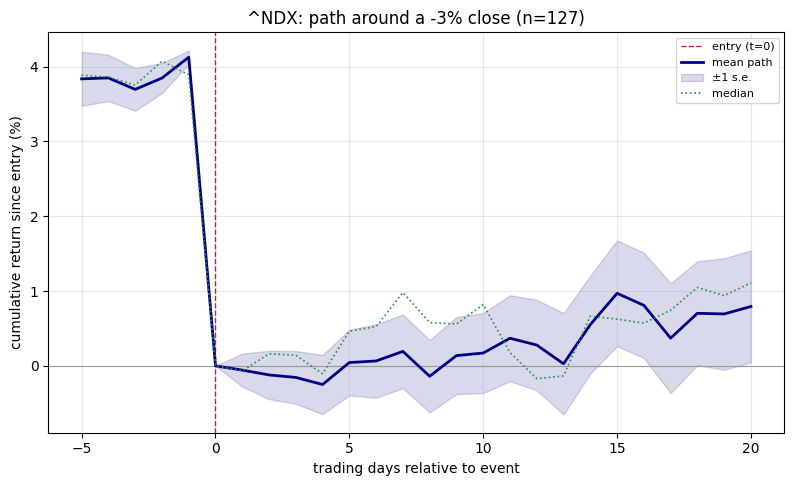

In [4]:
ev_ndx = triggers.first_crossings(triggers.close_to_close(ret_ndx, -0.03), cooldown=20)
es = eventstudy.event_study(ndx, ev_ndx, horizon=20, pre=5)
print(f"T1 close-to-close -3% | {es['n_events']} events")
display(es['summary'].loc[[1,3,5,10,20], ['mean','median','pct_positive','tstat']].round(4))
summ = es['summary']; n = es['n_events']; se = summ['std']/np.sqrt(max(n,1))
ax = plt.subplot(); ax.axhline(0, color='0.6', lw=.8); ax.axvline(0, color='crimson', ls='--', lw=1, label='entry (t=0)')
ax.plot(summ.index, summ['mean']*100, color='navy', lw=2, label='mean path')
ax.fill_between(summ.index, (summ['mean']-se)*100, (summ['mean']+se)*100, color='navy', alpha=.15, label='±1 s.e.')
ax.plot(summ.index, summ['median']*100, color='seagreen', ls=':', lw=1.2, label='median')
ax.set_xlabel('trading days relative to event'); ax.set_ylabel('cumulative return since entry (%)')
ax.set_title(f'^NDX: path around a -3% close (n={n})'); ax.legend(fontsize=8); ax.grid(alpha=.3); plt.show()

### 4.2 The decisive test — conditional vs a random day

The market drifts up regardless, so absolute forward returns are meaningless. Permute to get the **excess** of the post-dip return over the unconditional (random-day) baseline, with a one-sided p-value. Run it on both faces.

In [5]:
for lab, ohlc, ev in [('^NDX', ndx, ev_ndx),
                      ('QQQ', qqq, triggers.first_crossings(triggers.close_to_close(ret_qqq, -0.03), cooldown=20))]:
    b = benchmark.conditional_vs_unconditional(ohlc, ev, horizons=(1,5,10,20))
    print(f'\n[{lab}] conditional vs random day (excess>0 & p_greater<0.05 => beats random):')
    print(b[['n_events','mean_cond','mean_uncond','excess','p_greater']].to_string(float_format=lambda v: f'{v:+.4f}'))


[^NDX] conditional vs random day (excess>0 & p_greater<0.05 => beats random):
         n_events  mean_cond  mean_uncond  excess  p_greater
horizon                                                     
1             128    -0.0004      +0.0007 -0.0011    +0.7910
5             127    +0.0004      +0.0033 -0.0029    +0.8515
10            127    +0.0017      +0.0066 -0.0049    +0.8840
20            127    +0.0079      +0.0132 -0.0053    +0.8160



[QQQ] conditional vs random day (excess>0 & p_greater<0.05 => beats random):
         n_events  mean_cond  mean_uncond  excess  p_greater
horizon                                                     
1              90    -0.0042      +0.0005 -0.0047    +0.9960
5              89    -0.0059      +0.0025 -0.0085    +0.9865
10             89    +0.0046      +0.0050 -0.0004    +0.5475
20             89    +0.0017      +0.0100 -0.0083    +0.8820


On 40 years of ^NDX the −3% close is **worse** than a random day (negative excess, p≈0.8). On QQQ the excess is negative at **every** horizon (p≈0.5–0.99) — if anything the dip day does worse than an ordinary one. (An earlier revision of the data layer showed QQQ a faint positive lean by +10d; it was an artefact — a double split-adjustment fabricated a ~+100% overnight gap at QQQ's 2000-03-20 split, right in the middle of the dot-com events.) **At −3%, there is no edge.**

> 💡 **In plain words** — buying the −3% dip earns you, at best, what buying any day earns you. The drama is free; the alpha is not there.

### 4.3 Clustering-aware: the block bootstrap

−3% days bunch together (2008, 2020, 2022), so a permutation that assumes independent draws *overstates* significance. Resample in blocks to respect the clustering, and read the 95% CI on the +5d excess.

In [6]:
for lab, ohlc, ev in [('^NDX', ndx, ev_ndx),
                      ('QQQ', qqq, triggers.first_crossings(triggers.close_to_close(ret_qqq, -0.03), cooldown=20))]:
    bb = robustness.block_bootstrap_excess(ohlc, ev, horizon=5)
    print(f"[{lab}] +5d excess = {bb['mean']:+.4f}  95% CI [{bb['ci_low']:+.4f}, {bb['ci_high']:+.4f}]  P(excess<=0)={bb['p_excess_le_0']:.2f}")

[^NDX] +5d excess = -0.0030  95% CI [-0.0112, +0.0051]  P(excess<=0)=0.75


[QQQ] +5d excess = -0.0086  95% CI [-0.0181, +0.0010]  P(excess<=0)=0.96


### 4.4 Is −3% special? Sweep the threshold

A lone threshold that lights up while its neighbours are flat is data-mined. A *real* effect varies smoothly as you move the knob. Sweep the drop size on the close-to-close trigger and read the excess vs a random day at each horizon.

[^NDX] excess vs random day (%), threshold x horizon:


,1,5,10,20
threshold,,,,
-2%,-0.0000,-0.3800,-0.3700,-0.1500
-3%,-0.1100,-0.2900,-0.4900,-0.5300
-4%,-0.2600,0.4300,0.3500,0.5600
-5%,0.5300,0.5700,-0.1800,0.2400
-7%,3.0400,2.2500,2.0700,2.6100


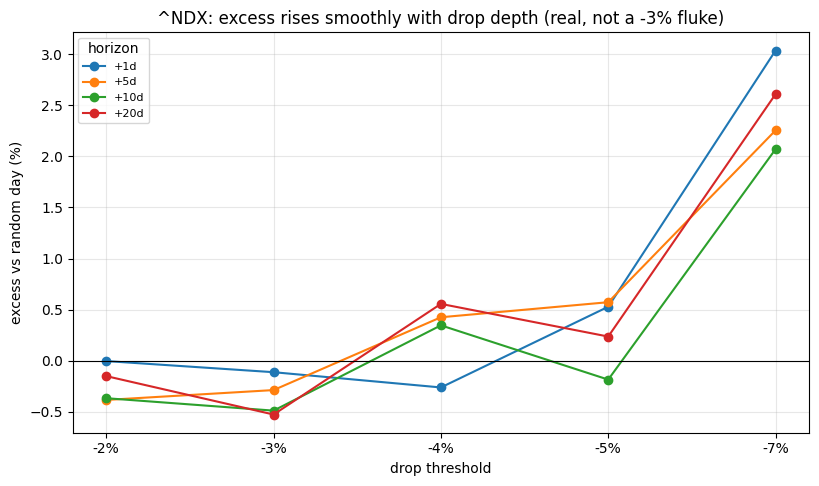

In [7]:
sw = sweeps.threshold_sweep(ndx, ret_ndx, trigger_fn=triggers.close_to_close)
exc = sw['excess']*100
print('[^NDX] excess vs random day (%), threshold x horizon:')
display(exc.round(2))
ax = plt.subplot()
for col in exc.columns:
    ax.plot(range(len(exc.index)), exc[col].values, marker='o', label=f'+{col}d')
ax.axhline(0, color='k', lw=.8)
ax.set_xticks(range(len(exc.index))); ax.set_xticklabels([str(i) for i in exc.index])
ax.set_xlabel('drop threshold'); ax.set_ylabel('excess vs random day (%)')
ax.set_title('^NDX: excess rises smoothly with drop depth (real, not a -3% fluke)')
ax.legend(title='horizon', fontsize=8); ax.grid(alpha=.3); plt.show()

The excess climbs **smoothly and monotonically** as the drop deepens — nothing at −3%, large and significant by −7%. That monotonicity is the fingerprint of a *real* mean-reversion effect that lives in genuine panic, not in a mild −3% wobble. The S&P 500 shows the same shape. **Signal: `WEAK` but real, in the tail.**

### 4.5 Panic zoom — overlay the depths

Visualise the monotonicity directly: overlay the mean forward paths for −3% / −5% / −7% on the deep-history spot index.

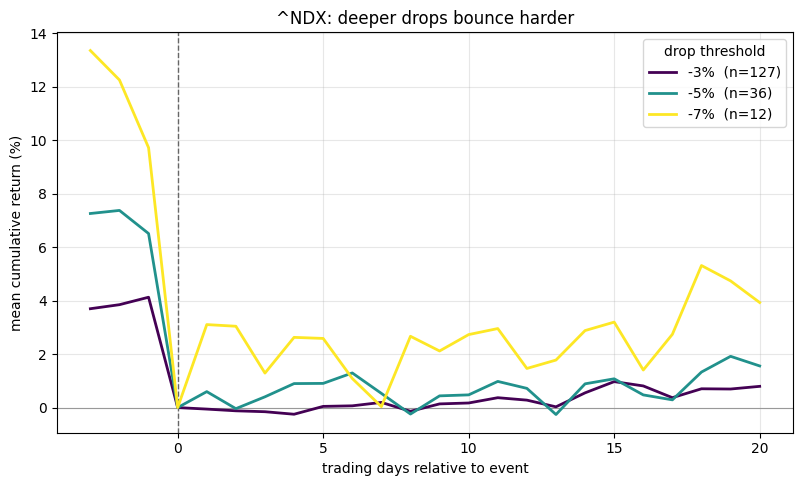

In [8]:
es_by = {}
for thr in (-0.03, -0.05, -0.07):
    ev = triggers.first_crossings(triggers.close_to_close(ret_ndx, thr), cooldown=20)
    es_by[f'{thr:.0%}'] = eventstudy.event_study(ndx, ev, horizon=20, pre=3)
ax = plt.subplot(); ax.axhline(0, color='0.6', lw=.8); ax.axvline(0, color='0.4', ls='--', lw=1)
cmap = plt.get_cmap('viridis'); items = list(es_by.items())
for i, (lab, r) in enumerate(items):
    s = r['summary']
    ax.plot(s.index, s['mean']*100, lw=2, color=cmap(i/max(len(items)-1, 1)), label=f"{lab}  (n={r['n_events']})")
ax.set_xlabel('trading days relative to event'); ax.set_ylabel('mean cumulative return (%)')
ax.set_title('^NDX: deeper drops bounce harder'); ax.legend(title='drop threshold'); ax.grid(alpha=.3); plt.show()

### 4.6 The absolute-Sharpe trap, live — family scan + deflation

Now the trap from beat 2, on real data. Scan the whole (trigger × exit) family on QQQ, rank by net Sharpe, and apply the deflated-Sharpe correction for having searched so many cells.

70 (trigger x exit) combos; top 6 by net Sharpe:


,trigger,exit,n_trades,active_days,cagr,sharpe,total_return,max_drawdown,win_rate,avg_hold_days
0,T3_drawdown_ATH,hold<=5d,51,254,0.0150,1.4940,0.5050,-0.1150,0.6470,4.9800
1,T3_drawdown_ATH,hold<=10d,51,503,0.0260,1.4170,1.0090,-0.1780,0.7450,9.8820
2,T3_drawdown_20d,hold<=3d,157,471,0.0260,1.4060,0.9880,-0.2090,0.5920,3.0000
3,T3_drawdown_20d,hold<=1d,157,157,0.0070,1.3130,0.2050,-0.1200,0.5670,1.0000
4,T3_drawdown_20d,hold<=5d tp+5% sl-5%,157,714,0.0240,1.0640,0.9100,-0.1940,0.5730,4.5480
5,T3_drawdown_20d,hold<=5d,157,784,0.0300,1.0590,1.2470,-0.2650,0.5800,4.9940


best raw Sharpe = 1.49 (T3_drawdown_ATH) over 70 trials, 254 active days -> deflated PSR = 0.18 (consistent with luck)


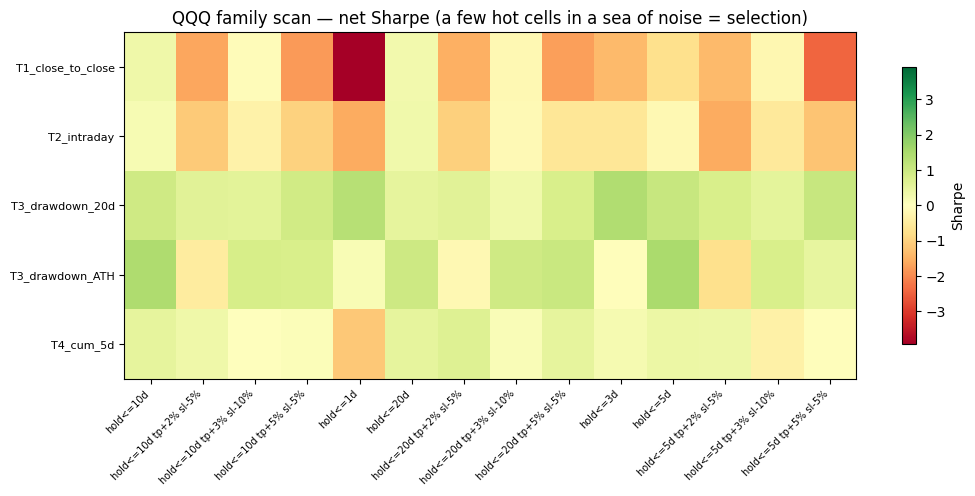

In [9]:
sigs = {nm: f(ret_qqq) for nm, f in triggers.TRIGGERS.items()}
scan = backtest.family_scan(qqq, ret_qqq, sigs, exits.default_grid(), costs=backtest.CostModel())
print(f'{len(scan)} (trigger x exit) combos; top 6 by net Sharpe:')
display(scan.head(6).round(3))
best = scan.iloc[0]
# n_obs = the active days behind the winning Sharpe, NOT the calendar length:
# the strategy is flat >90% of the time, and inflating n_obs to the full sample
# makes the deflation test trivially easy to pass.
dsr = robustness.deflated_sharpe(best['sharpe'], n_trials=len(scan), n_obs=int(best['active_days']))
print(f"best raw Sharpe = {best['sharpe']:.2f} ({best['trigger']}) over {len(scan)} trials, "
      f"{int(best['active_days'])} active days -> "
      f"deflated PSR = {dsr:.2f} ({'survives selection' if dsr and dsr>0.95 else 'consistent with luck'})")
pivot = scan.pivot(index='trigger', columns='exit', values='sharpe')
vmax = np.nanmax(np.abs(pivot.to_numpy()))
fig, ax = plt.subplots(figsize=(min(2+0.7*pivot.shape[1], 15), 2+0.5*pivot.shape[0]))
im = ax.imshow(pivot.to_numpy(), aspect='auto', cmap='RdYlGn', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(pivot.shape[1])); ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(pivot.shape[0])); ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_title('QQQ family scan — net Sharpe (a few hot cells in a sea of noise = selection)')
fig.colorbar(im, ax=ax, shrink=0.8, label='Sharpe'); plt.show()

Counted honestly — `n_obs` = the ~250 days the winner actually spends in the market, not the ~6,800-day calendar — the best cell **fails deflation** (PSR far below the 0.95 bar): the prettiest Sharpe in the grid is consistent with picking the luckiest of 70 coin-flips. And even if it had survived, watch what a **regime split** does to it. Run the representative tradeable rule and break the P&L out by era:

[T3_drawdown_ATH, hold<=5d, retail costs]  trades=51  CAGR=+1.51%  Sharpe=1.49  maxDD=-11.5%

Regime split — is it one lucky era?


,start,total_return,sharpe,active_days
regime,,,,
Dot-com bust,2000-01-01,-0.0302,-0.3156,15
Mid-2000s bull,2003-01-01,0.0000,NaN,0
GFC,2007-11-01,0.0000,NaN,0
QE bull,2009-04-01,0.0390,0.5769,90
COVID crash,2020-02-20,-0.0234,-1.7186,5
Post-COVID bull,2020-05-01,0.1115,2.4833,50
2022 bear,2022-01-01,0.0070,2.4159,5
Recent,2023-01-01,0.0885,1.9066,59


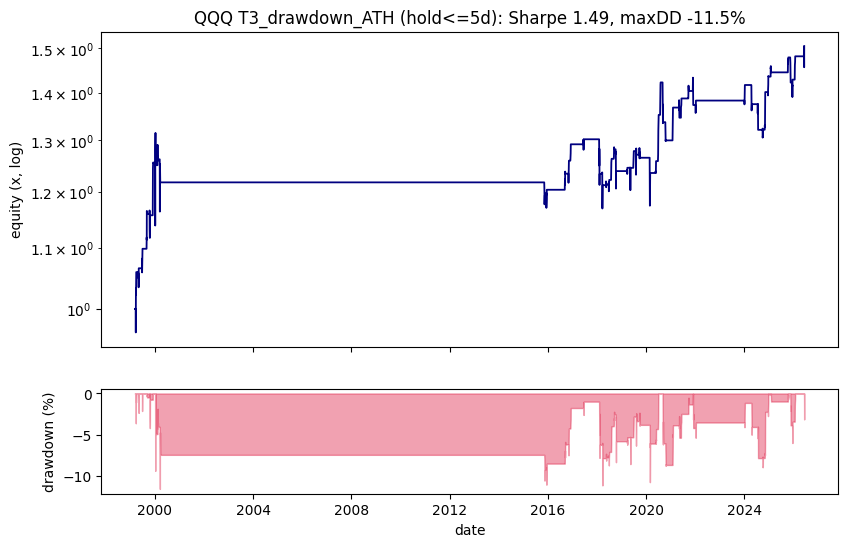

In [10]:
best_sig = triggers.first_crossings(sigs[best['trigger']], cooldown=20)
res = backtest.run(qqq, best_sig, exits.ExitRule(max_hold=5), backtest.CostModel())
print(f"[{best['trigger']}, hold<=5d, retail costs]  trades={res.stats['n_trades']}  "
      f"CAGR={res.stats['cagr']:+.2%}  Sharpe={res.stats['sharpe']:.2f}  maxDD={res.stats['max_drawdown']:.1%}")
print('\nRegime split — is it one lucky era?')
display(robustness.regime_split(res.daily).round(4))
eq = res.equity; dd = eq/eq.cummax()-1
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.5, 6), sharex=True, gridspec_kw={'height_ratios':[3,1]})
a1.plot(eq.index, eq.values, color='navy', lw=1.3); a1.set_yscale('log'); a1.set_ylabel('equity (x, log)')
a1.set_title(f"QQQ {best['trigger']} (hold<=5d): Sharpe {res.stats['sharpe']:.2f}, maxDD {res.stats['max_drawdown']:.1%}")
a2.fill_between(dd.index, dd.values*100, 0, color='crimson', alpha=.4); a2.set_ylabel('drawdown (%)'); a2.set_xlabel('date'); plt.show()

The headline Sharpe is **leveraged exposure to whether the dip keeps dipping**: it pays spectacularly when the Fed backstops every selloff and bleeds in the one bear market without a quick rescue. That's not a stable edge — it's beta to the "Fed put."

> 💡 **In plain words** — the great-looking backtest isn't finding a dip edge; it's just long the market with extra steps, and it only shines in the decades where the market shot straight up.

### 4.7 Does it generalise? Nasdaq vs S&P 500, in/out-of-sample

A genuine mechanism should (a) be significant, (b) appear on **both** indices, and (c) survive out-of-sample. We pick the best family cell on the first 60% of history and test it on the unseen tail — for all four faces.

In [11]:
rows = []
for lab, (spot, etf) in data.INDEX_PAIRS.items():
    for face, tk in [('spot', spot), ('ETF', etf)]:
        o = data.fetch(tk, mode='split_only'); r = data.daily_returns(o)
        ev = triggers.first_crossings(triggers.close_to_close(r, -0.03), cooldown=20)
        b = benchmark.conditional_vs_unconditional(o, ev, horizons=(1,5,10,20))
        sg = {nm: f(r) for nm, f in triggers.TRIGGERS.items()}
        oos = robustness.oos_best_cell(o, sg, exits.default_grid())
        rows.append({'index': f'{lab} {face}', 'ticker': tk,
                     '-3% +5d excess': f"{b.loc[5,'excess']:+.2%}" if 5 in b.index else 'na',
                     'p': f"{b.loc[5,'p_greater']:.2f}" if 5 in b.index else 'na',
                     'best cell': oos.get('trigger','?'),
                     'Sharpe IS': f"{oos.get('is_sharpe', float('nan')):.2f}",
                     'Sharpe OOS': f"{oos.get('oos_sharpe', float('nan')):.2f}"})
pd.DataFrame(rows).set_index('index')

,ticker,-3% +5d excess,p,best cell,Sharpe IS,Sharpe OOS
index,,,,,,
Nasdaq-100 spot,^NDX,-0.29%,0.85,T3_drawdown_ATH,1.98,1.77
Nasdaq-100 ETF,QQQ,-0.85%,0.99,T3_drawdown_ATH,3.74,0.56
S&P 500 spot,^GSPC,-0.26%,0.89,T2_intraday,4.23,2.41
S&P 500 ETF,SPY,+0.14%,0.35,T1_close_to_close,3.45,-5.42


The −3% non-edge is identical on both indices. The flashy family-scan Sharpes survive only on the *spot* faces (that's the persistent market drift); on the *tradeable* ETFs the winners **collapse out-of-sample** — textbook data-mining. **Generalisation fails where it has to: on the things you could actually trade.**

## 5 · The verdict

1. **−3% is folklore — `NONE`.** Excess over a random day is ~0 on the Nasdaq *and* the S&P 500; any flattering Sharpe is market beta that dies out-of-sample.
2. **Deep panic is real — `WEAK`.** The bounce grows smoothly with depth and is significant by permutation at −5%/−7% on both indices — a genuine statistical fingerprint of panic mean-reversion.
3. **…but it isn't tradeable — `MIRAGE`.** Under the clustering-aware bootstrap the deep-dip excess straddles zero (the permutation overstated it), the events are rare and crash-dominated, and a fixed rule flips sign out-of-sample.

The round number is a myth; even the panic tail — the one place the effect is statistically visible — doesn't survive clustering, capacity and out-of-sample scrutiny. At most it's a *behavioural discipline for deploying long-term capital into a crash*, never a standalone alpha engine.

## 6 · Could you actually harvest it? (capacity, stability, cost)

The deep-dip bounce is *true* but ask whether it's *bankable*. First, **capacity** — how often do these events even happen, and how concentrated are they?

In [12]:
def capacity(ev, ohlc):
    dates = ev.index[ev.to_numpy()]; years = ohlc.shape[0]/252.0; nn = len(dates)
    by_year = pd.Series(dates).dt.year.value_counts().sort_values(ascending=False)
    return nn, (10*nn/years if years else np.nan), list(by_year.head(2).index), (by_year.head(2).sum()/nn if nn else np.nan)
print('[^NDX] deep-dip capacity:')
for thr in (-0.03, -0.05, -0.07):
    ev = triggers.first_crossings(triggers.close_to_close(ret_ndx, thr), cooldown=20)
    nn, perdec, top2, share = capacity(ev, ndx)
    print(f'  {thr:+.0%}: {nn:>3} events | {perdec:>4.1f}/decade | top-2 years {top2} = {share:.0%} of all events')

[^NDX] deep-dip capacity:
  -3%: 128 events | 31.5/decade | top-2 years [2000, 2001] = 17% of all events
  -5%:  36 events |  8.8/decade | top-2 years [2001, 2000] = 36% of all events
  -7%:  12 events |  2.9/decade | top-2 years [2000, 2001] = 50% of all events


A −7% day fires ~3×/decade and a large share of those sit in 2–3 historic crashes. You're not running a strategy; you're betting on a handful of selloffs. Next, **stability** — does a fixed −5% rule survive out-of-sample?

In [13]:
raw5 = triggers.close_to_close(ret_ndx, -0.05)
is_o, oos_o = robustness.split_sample(ndx, 0.6)
rows = {}
for tag, seg in (('IS (first 60%)', is_o), ('OOS (last 40%)', oos_o)):
    sig = triggers.first_crossings(raw5.reindex(seg.index), cooldown=20)
    r = backtest.run(seg, sig, exits.ExitRule(max_hold=5), backtest.CostModel())
    rows[tag] = {'trades': r.stats['n_trades'], 'CAGR': r.stats['cagr'], 'Sharpe': r.stats['sharpe'], 'maxDD': r.stats['max_drawdown']}
display(pd.DataFrame(rows).T.round(4))

,trades,CAGR,Sharpe,maxDD
IS (first 60%),29.0000,0.0149,1.3003,-0.2631
OOS (last 40%),7.0000,-0.0106,-1.3496,-0.3069


In-sample winner, out-of-sample loser — the Sharpe flips sign. Finally, **cost** — and here's the twist vs the overnight study: because you trade so rarely, costs are *not* the killer.

,cagr,sharpe,total_return,max_drawdown,n_trades
panic_slippage_bps,,,,,
0,0.0068,0.8914,0.2032,-0.2334,25
5,0.0064,0.8523,0.1883,-0.2342,25
10,0.0059,0.8133,0.1736,-0.2350,25
20,0.0050,0.7350,0.1446,-0.2375,25
40,0.0031,0.5782,0.0888,-0.2438,25


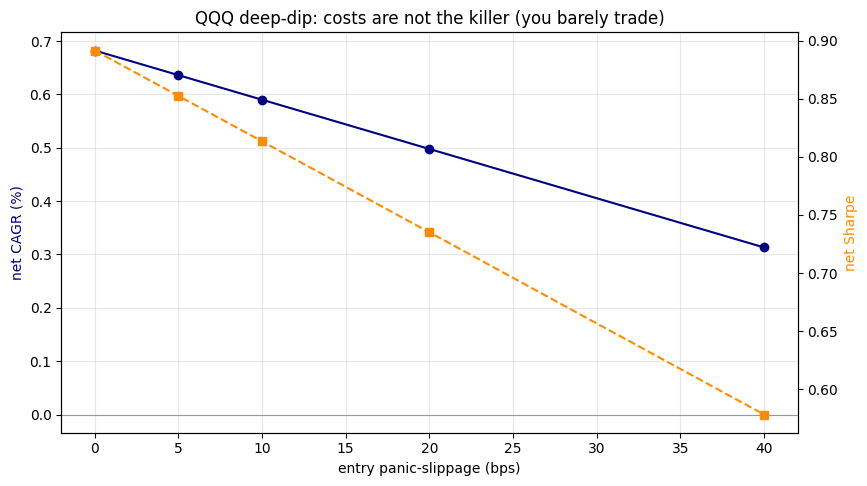

In [14]:
ev5_qqq = triggers.first_crossings(triggers.close_to_close(ret_qqq, -0.05), cooldown=20)
sweep = backtest.cost_sweep(qqq, ev5_qqq, exits.ExitRule(max_hold=5))
display(sweep.round(4))
ax = plt.subplot(); ax.axhline(0, color='0.6', lw=.8)
ax.plot(sweep.index, sweep['cagr']*100, 'o-', color='navy', label='CAGR (%)'); ax.set_xlabel('entry panic-slippage (bps)'); ax.set_ylabel('net CAGR (%)', color='navy')
ax2 = ax.twinx(); ax2.plot(sweep.index, sweep['sharpe'], 's--', color='darkorange', label='Sharpe'); ax2.set_ylabel('net Sharpe', color='darkorange')
ax.set_title('QQQ deep-dip: costs are not the killer (you barely trade)'); ax.grid(alpha=.3); plt.show()

Even a brutal entry slippage barely dents the Sharpe — it never flips it negative. **The thing standing between you and profit isn't transaction cost; it's that there's little excess edge over plain beta to begin with.** That's the `MIRAGE` stamp: real in the data, unbankable in practice.

> 💡 **In plain words** — you can't fix a non-edge with cheaper trading. The problem was never the toll; it's that the road doesn't go anywhere.

## 7 · Going further

**What would change the verdict.** Toward `INVESTABLE`: a deep-dip excess whose *block-bootstrap* CI clears zero and that survives an honest out-of-sample split — ideally with enough events to size a real book (these don't). Toward a richer signal: condition on volatility regime, breadth, or credit stress rather than price alone; the panic bounce may be a *conditional* effect we've only measured marginally.

**Reproducibility.** The package ships a 24-test offline suite (`pytest -q`) covering the return identities, the conservative intrabar fill (stop-before-target), cost monotonicity, the single-position no-overlap guarantee, and — crucially — that the benchmark **detects an injected edge and stays flat when there is none**. Start with `examples/run_synthetic_demo.py` (offline) to see the toolchain tell a real edge from a fake one, then `examples/verify_ndx.py`, `sweep_thresholds.py`, `panic_zoom.py`, `compare_indices.py` for the live studies.

**The real deliverable is the method.** Any backtest that skips the random-day benchmark, the threshold sweep, the block bootstrap and an out-of-sample split is marketing. New studies follow the same seven beats ([METHODOLOGY.md](../../../METHODOLOGY.md)).

## Caveats (read before quoting any number)

1. **Event clustering** shrinks the effective sample far below the raw count.
2. **Regime dependence** — dip-buying loves a "Fed put" and hates a 2000–2002 grind. One great decade is not a law.
3. **Short-vol profile** — you add risk exactly when volatility peaks; a positive average can hide an ugly tail. Watch max drawdown, not just CAGR.
4. **Execution reality** — the −3% close on a chart is a print you may not get; modelled `panic_slippage_bps` is a guess, so sweep it.

MIT licensed, research & teaching only — **not investment advice.** Numbers extend as new data arrives.